# Finance & Economics Job Market Analysis

## Project Overview

This project analyzes LinkedIn job postings to investigate the finance and economics job market.

Research questions:

1. What finance and economics roles are most common?
2. What skills appear most frequently?
3. How does salary vary by experience level?
4. Which skills are associated with higher compensation?
5. How does the finance job market compare with the data science job market?

Dataset:
LinkedIn Job Postings (2023–2024)
~124,000 job postings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub

In [2]:
# Download dataset

path = kagglehub.dataset_download(
    "arshkon/linkedin-job-postings"
)

print("Dataset path:")
print(path)

Dataset path:
/Users/lavin/.cache/kagglehub/datasets/arshkon/linkedin-job-postings/versions/13


In [3]:
# Inspect files

print("Files in dataset:")

for root, dirs, files in os.walk(path):

    print("\n", root)

    for file in files[:10]:
        print("  ", file)

Files in dataset:

 /Users/lavin/.cache/kagglehub/datasets/arshkon/linkedin-job-postings/versions/13
   postings.csv

 /Users/lavin/.cache/kagglehub/datasets/arshkon/linkedin-job-postings/versions/13/mappings
   skills.csv
   industries.csv

 /Users/lavin/.cache/kagglehub/datasets/arshkon/linkedin-job-postings/versions/13/jobs
   benefits.csv
   salaries.csv
   job_industries.csv
   job_skills.csv

 /Users/lavin/.cache/kagglehub/datasets/arshkon/linkedin-job-postings/versions/13/companies
   company_industries.csv
   company_specialities.csv
   companies.csv
   employee_counts.csv


In [4]:
postings_path = os.path.join(
    path,
    "postings.csv"
)

postings = pd.read_csv(
    postings_path,
    low_memory=False
)

print(postings.shape)

postings.head()

(123849, 31)


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [5]:
postings.columns.tolist()

['job_id',
 'company_name',
 'title',
 'description',
 'max_salary',
 'pay_period',
 'location',
 'company_id',
 'views',
 'med_salary',
 'min_salary',
 'formatted_work_type',
 'applies',
 'original_listed_time',
 'remote_allowed',
 'job_posting_url',
 'application_url',
 'application_type',
 'expiry',
 'closed_time',
 'formatted_experience_level',
 'skills_desc',
 'listed_time',
 'posting_domain',
 'sponsored',
 'work_type',
 'currency',
 'compensation_type',
 'normalized_salary',
 'zip_code',
 'fips']

## Creating a Finance and Economics Subset

The LinkedIn dataset contains job postings from many industries and professions.

To focus the analysis, a subset of finance and economics-related positions will be created using job title keywords.

Examples include:

- Finance
- Financial Analysis
- Investment
- Banking
- Economics
- Risk
- Credit
- Portfolio Management
- Trading
- Quantitative Analysis

In [6]:
finance_keywords = [
    "finance",
    "financial",
    "investment",
    "investor",
    "banking",
    "equity",
    "portfolio",
    "risk",
    "credit",
    "economist",
    "economic",
    "economics",
    "trading",
    "quant",
    "quantitative",
    "treasury",
    "valuation",
    "wealth"
]

pattern = "|".join(finance_keywords)

finance_df = postings[
    postings["title"]
        .str.lower()
        .str.contains(pattern, na=False)
].copy()

print("Finance/Econ postings:")
print(finance_df.shape)

finance_df[
    [
        "title",
        "company_name",
        "location",
        "formatted_experience_level",
        "normalized_salary"
    ]
].head(20)

Finance/Econ postings:
(3912, 31)


,title,company_name,location,formatted_experience_level,normalized_salary
5,Economic Development and Planning Intern,Downtown Raleigh Alliance,"Raleigh, NC",NaN,35360.0
60,Equity Institutional Sales Position,A.G.P./Alliance Global Partners,New York City Metropolitan Area,NaN,NaN
70,Entry Level Oracle Financial Technology Consul...,Revature,"East Chicago, IN",Entry level,NaN
125,"Director, Investment Sales",Kenai Capital Advisors,"Littleton, CO",NaN,20000.5
209,Director of Finance,Society of St. Vincent de Paul Detroit,"Detroit, MI",NaN,105000.0
309,Community Association Manager- Portfolio,CAMS (Community Association Management Services),"Morehead City, NC",NaN,49000.0
346,Financial Advisor,Shah Financial,"Red Bank, NJ",NaN,102500.0
374,Financial Services Representative,"Five Rings Financial, LLC",United States,NaN,125002.5
377,Investor Relations Associate,MZ North America,United States,NaN,72500.0
387,"Senior Director, Clinical Pharmacology & Quant...",AstraZeneca,"Gaithersburg, MD",Mid-Senior level,NaN


In [7]:
finance_df["title"].value_counts().head(30)

title
Financial Analyst                                113
Financial Advisor                                 91
US Experienced Financial Advisor                  69
Senior Financial Analyst                          68
Chief Financial Officer                           48
Finance Manager                                   45
Financial Controller                              40
Director of Finance                               25
Oracle Financial Technology Associate             16
Sr. Financial Analyst                             15
Financial Representative                          14
Vice President Finance                            14
Portfolio Manager                                 14
Financial Services Professional                   14
Financial Planning and Analysis Manager           12
Financial Services Representative                 11
Financial Accountant                              10
Treasury Analyst                                  10
Financial Contract Analyst – Overland Pa

## Finance and Economics Subset Results

Using finance and economics-related keywords, a subset of 3,912 job postings was extracted from the full LinkedIn dataset.

### Most Common Roles

The most frequently occurring titles include:

- Financial Analyst
- Financial Advisor
- Senior Financial Analyst
- Chief Financial Officer (CFO)
- Finance Manager
- Financial Controller
- Director of Finance
- Portfolio Manager
- Treasury Analyst
- Risk Manager

These results suggest the subset successfully captures a broad range of finance, investment, accounting, treasury, and leadership positions.

In [8]:
finance_df["formatted_experience_level"].value_counts(dropna=False)

formatted_experience_level
Mid-Senior level    1617
NaN                  921
Entry level          499
Associate            429
Director             235
Executive            156
Internship            55
Name: count, dtype: int64

## Experience Level Distribution

The finance and economics subset contains a broader range of experience levels than the data science dataset.

### Experience Distribution

- Mid-Senior Level: 1,617
- Entry Level: 499
- Associate: 429
- Director: 235
- Executive: 156
- Internship: 55

### Interpretation

Unlike the data science dataset, which was heavily concentrated in senior positions, the finance dataset contains a larger proportion of early-career opportunities.

This suggests that finance and economics roles may offer a more visible entry-level hiring pipeline on LinkedIn compared to data science positions.

In [9]:
finance_df.groupby(
    "formatted_experience_level"
)["normalized_salary"].mean().sort_values()

formatted_experience_level
Internship           59390.577778
Entry level          88805.366704
Associate           102099.892308
Mid-Senior level    128161.950174
Director            193582.729348
Executive           226922.663462
Name: normalized_salary, dtype: float64

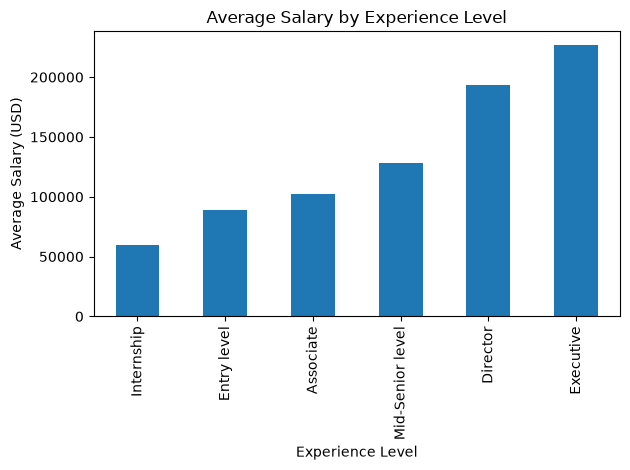

In [10]:
salary_by_exp = (
    finance_df.groupby(
        "formatted_experience_level"
    )["normalized_salary"]
    .mean()
    .sort_values()
)

salary_by_exp.plot(kind="bar")

plt.title("Average Salary by Experience Level")
plt.ylabel("Average Salary (USD)")
plt.xlabel("Experience Level")

plt.tight_layout()
plt.savefig(

    "../images/finance_avg_salary_by_experience.png",

    dpi=300,

    bbox_inches="tight"

)
plt.show()

## Salary by Experience Level

Average salaries increase consistently across experience levels.

| Experience Level | Average Salary (USD) |
|------------------|--------------------:|
| Internship | 59,391 |
| Entry Level | 88,805 |
| Associate | 102,100 |
| Mid-Senior Level | 128,162 |
| Director | 193,583 |
| Executive | 226,923 |

### Observations

A strong positive relationship exists between experience level and compensation.

The largest increase occurs between Mid-Senior and Director roles, suggesting that leadership and management responsibilities are highly valued within finance and economics-related careers.

Compared with the data science dataset, the finance job market appears to contain a broader range of entry-level opportunities while still offering substantial salary growth through career progression.

In [11]:
job_skills_path = os.path.join(
    path,
    "jobs",
    "job_skills.csv"
)

job_skills = pd.read_csv(job_skills_path)

print(job_skills.shape)

job_skills.head()

skills_path = os.path.join(
    path,
    "mappings",
    "skills.csv"
)

skills = pd.read_csv(skills_path)

print(skills.shape)

skills.head()


job_skills.columns.tolist()

skills.columns.tolist()

(213768, 2)
(35, 2)


['skill_abr', 'skill_name']

In [12]:
skills.head()


,skill_abr,skill_name
0,ART,Art/Creative
1,DSGN,Design
2,ADVR,Advertising
3,PRDM,Product Management
4,DIST,Distribution


In [13]:
job_skills.head()

,job_id,skill_abr
0,3884428798,MRKT
1,3884428798,PR
2,3884428798,WRT
3,3887473071,SALE
4,3887465684,FIN


In [14]:
job_skills_full = job_skills.merge(
    skills,
    on="skill_abr",
    how="left"
)

finance_skills = job_skills_full.merge(
    finance_df[["job_id"]],
    on="job_id",
    how="inner"
)

print("Finance skills shape:", finance_skills.shape)

finance_skills.head()

Finance skills shape: (7456, 3)


,job_id,skill_abr,skill_name
0,3884916106,SALE,Sales
1,3884916106,BD,Business Development
2,3884916106,GENB,General Business
3,3884432468,IT,Information Technology
4,3813844724,FIN,Finance


In [15]:
finance_skill_counts = finance_skills["skill_name"].value_counts()

finance_skill_counts.head(20)

skill_name
Finance                   2521
Sales                     1787
Accounting/Auditing        628
Information Technology     436
Analyst                    240
Business Development       234
Management                 193
Other                      172
Consulting                 164
Engineering                126
Strategy/Planning          108
Administrative             103
Research                    81
Marketing                   80
General Business            78
Manufacturing               75
Project Management          61
Customer Service            51
Legal                       50
Health Care Provider        39
Name: count, dtype: int64

## Finance/Economics Skill Demand

The dataset stores job skills in separate relational tables.

To analyze skill demand, I joined:

- `job_skills.csv`, which links each job posting to skill abbreviations
- `skills.csv`, which maps skill abbreviations to readable skill names
- the finance/economics job subset using `job_id`

This creates a finance-specific skills table that can be used to identify the most common skill categories in finance and economics-related roles.

## Skill Category Results

After joining the finance/economics subset with LinkedIn's structured skills tables, the most common skill categories were:

- Finance
- Sales
- Accounting/Auditing
- Information Technology
- Analyst
- Business Development
- Management
- Consulting

### Interpretation

These skills appear to represent broad LinkedIn skill categories rather than specific technical tools.

The results suggest that finance/economics-related postings often overlap with sales, accounting, IT, business development, and management functions.

Because this table does not provide detailed tool-level skills such as Excel, SQL, Python, or Tableau, additional keyword extraction from job descriptions may be needed for a more detailed technical skills analysis.

In [16]:
tool_keywords = [
    "excel",
    "sql",
    "python",
    "tableau",
    "power bi",
    "financial modeling",
    "valuation",
    "forecasting",
    "vba",
    r"\br\b",
    "bloomberg",
    "risk management",
    "accounting",
    "data analysis",
    "machine learning"
]

tool_counts = {}

for tool in tool_keywords:
    count = finance_df["description"].str.lower().str.contains(
        tool,
        na=False,
        regex=True
    ).sum()

    tool_counts[tool] = count

pd.Series(tool_counts).sort_values(ascending=False)

excel                 2420
accounting            1661
risk management        641
forecasting            606
valuation              480
financial modeling     289
sql                    250
data analysis          227
\br\b                  190
python                 179
tableau                127
power bi               120
machine learning        65
bloomberg               55
vba                     38
dtype: int64

In [17]:
tool_counts_series = (
    pd.Series(tool_counts)
    .sort_values(ascending=False)
)

tool_counts_series.head(10)

excel                 2420
accounting            1661
risk management        641
forecasting            606
valuation              480
financial modeling     289
sql                    250
data analysis          227
\br\b                  190
python                 179
dtype: int64

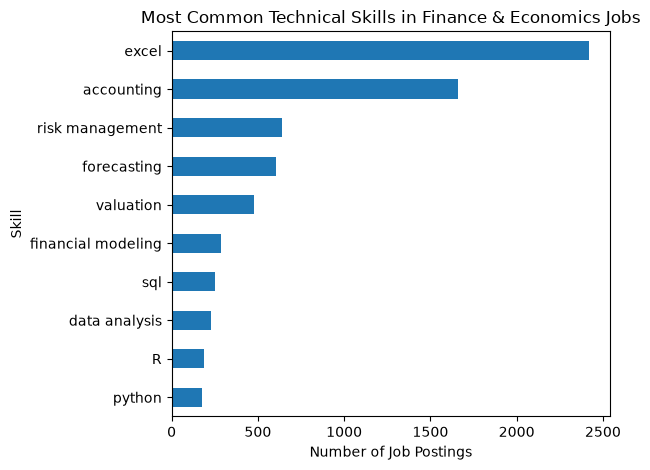

In [18]:

tool_counts_series.index = [
    "R" if x == r"\br\b" else x
    for x in tool_counts_series.index
]

tool_counts_series.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Most Common Technical Skills in Finance & Economics Jobs")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")

plt.tight_layout()
plt.savefig(

    "../images/finance_top_skills.png",

    dpi=300,

    bbox_inches="tight"

)
plt.show()